In [2]:
import importlib
import sys
sys.path.append("/home/nichettg/Linux Programmi/Codici")

import numpy as np
import funzioni as f
importlib.reload(f)

import matplotlib.pyplot as plt
import grafici as gf
importlib.reload(gf)

<module 'grafici' from '/home/nichettg/Linux Programmi/Codici/grafici.py'>

# 1. Raccolta Dati

In [3]:
def converti(P_kgcm2, V_cm3, T_C):
    
    # 1 kg/cm² = 98_066.5 Pa
    P_Pa = 98066.5 * P_kgcm2
    # 1 cm³ = 1e-6 m³
    V_m3 = 1e-6 * V_cm3
    # °C to K
    T_K = T_C + 273.15

    return P_Pa, V_m3, T_K

In [4]:
import os

input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir('./Data'))]
dati = []

for input_file in input_files:

    array = np.loadtxt(input_file)
    P = array[:, 0]  # prima colonna: pressione
    V = array[:, 1]  # seconda colonna: volume
    T = array[:, 2]  # terza colonna: temperatura
    dati.append(converti(P, V, T))

In [5]:
from tabulate import tabulate

for i, (P, V, T) in enumerate(dati):
    print(f"\nTemperatura {i+1}5 °C:\n")
    rows = list(zip(P, V, T))
    headers = ["P [Pa]", "V [m³]", "T [K]"]
    print(tabulate(rows, headers=headers, floatfmt=(".2f", ".8f", ".2f")))


Temperatura 15 °C:

   P [Pa]      V [m³]    T [K]
---------  ----------  -------
105421.49  0.00002359   288.16
105421.49  0.00002359   288.16
105421.49  0.00002359   288.16
105421.49  0.00002359   288.16
105421.49  0.00002359   288.17
105421.49  0.00002359   288.17
105421.49  0.00002359   288.17
105421.49  0.00002359   288.18
105421.49  0.00002359   288.18
105421.49  0.00002359   288.18
105421.49  0.00002359   288.19
105421.49  0.00002359   288.19
105421.49  0.00002359   288.19
105421.49  0.00002359   288.19
105421.49  0.00002359   288.20
105421.49  0.00002359   288.20
105421.49  0.00002359   288.20
105421.49  0.00002359   288.21
105421.49  0.00002359   288.21
105421.49  0.00002359   288.21
105421.49  0.00002359   288.21
105421.49  0.00002359   288.22
105421.49  0.00002359   288.22
105421.49  0.00002359   288.22
105421.49  0.00002359   288.23
105421.49  0.00002359   288.23
105421.49  0.00002359   288.23
105421.49  0.00002359   288.23
105421.49  0.00002359   288.23
105421.49  0.00002

# 2. Fit Lineare Volume e Grafico

In [6]:
sx = 0.01 / np.sqrt(12)
sy = 0.00000001 / np.sqrt(12)

parametri = []

for i,serie in enumerate(dati):
    output_filename = input_files[i].replace( "Data", "Elaborati")
    a,b,sa,sb,cov,p = f.elaborato(1/serie[0], serie[1], sy, output_filename, i, sx/(serie[0]**2), ritorno = True)
    parametri.append(np.array([a, b, sa, sb]))

Incertezze y uniformi
Incertezze x uniformi
Incertezze y uniformi
Incertezze x uniformi
Incertezze y uniformi
Incertezze x uniformi
Incertezze y uniformi
Incertezze x variabili
Incertezze y uniformi
Incertezze x uniformi


In [10]:
rows=[]
for i, (a, b, sa, sb) in enumerate(parametri):
    rows.append([(i+1)*10 + 5, a, b, sa, sb])
headers = ["Temperatura [°C]", "a", "b", "sa", "sb"]
print(tabulate(rows, headers=headers, floatfmt=(".6f", ".10f", ".6f", ".10f", ".6f")))

  Temperatura [°C]              a         b            sa        sb
------------------  -------------  --------  ------------  --------
                15  -0.0000007961  2.576060  0.0000000132  0.002230
                25  -0.0000011657  2.705470  0.0000000145  0.002257
                35  -0.0000009711  2.784028  0.0000000103  0.001665
                45  -0.0000010864  2.889767  0.0000000075  0.001302
                55  -0.0000014826  2.994575  0.0000000238  0.004059


/home/nichettg/Linux Programmi/Codici/grafici.py:57: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


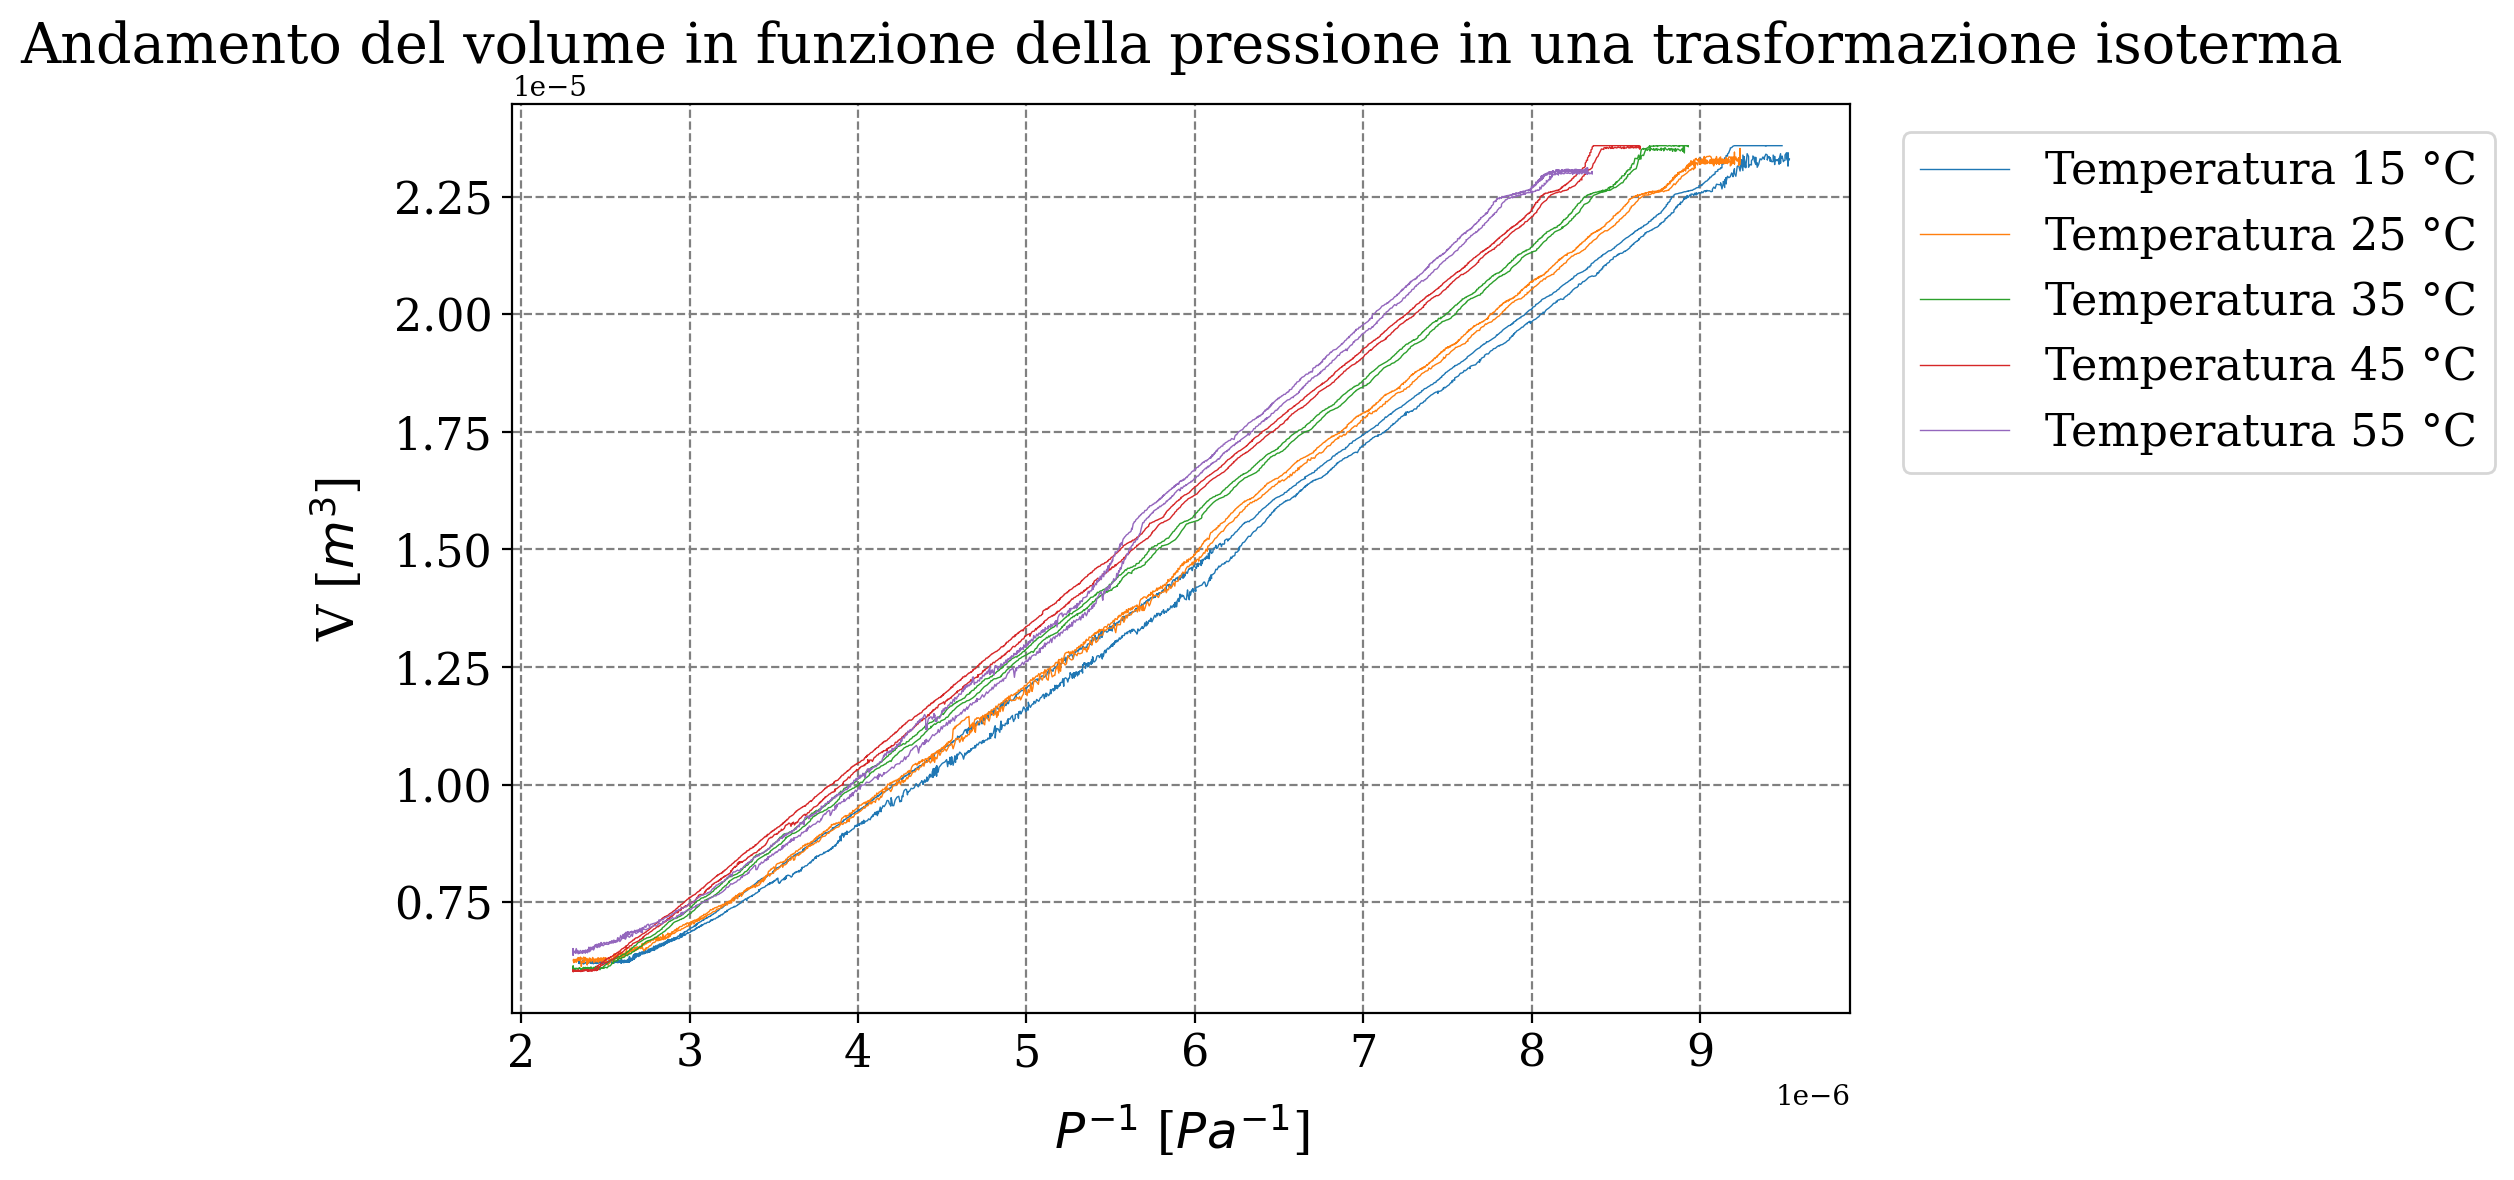

In [16]:
import itertools
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
color_cycle = itertools.cycle(colors)
markers = ['o','s','^','D','v']
marker_cycle = itertools.cycle(markers)
errori = gf.default_error_params()
gf.imposta_stile_globale()

fig, ax = plt.subplots()

for i,serie in enumerate(dati):
    color = next(color_cycle)
    temperatura = (i+1)*10 + 5
    marker = next(marker_cycle)
    label = f"Temperatura {temperatura} °C"
    #ax.errorbar(1/serie[0], serie[1], xerr=sx/serie[0]**2, yerr=sy, fmt=marker, label=label, color=color, **errori)
    ax.plot(1 / serie[0], serie[1], linewidth=0.5, label=label, color=color)

gf.parametri_grafico(ax, titolo = "Andamento del volume in funzione della pressione in una trasformazione isoterma", xlabel = "$P^{-1}$ [$Pa^{-1}$]", ylabel = "V [$m^{3}$]")

gf.salva_grafico(fig, f"./Images/Confronto.pdf", legenda=(1,0.9))